In [1]:
import numpy as np
import json

import rasterio
import cv2

import matplotlib.pyplot as plt

In [2]:
rgb_path = "25.9231767_-80.18102429999999_nearmap_rgb.tif"
dsm_path = "25.9231767_-80.18102429999999_nearmap_dsm.tif"

In [3]:
with rasterio.open(rgb_path) as src:
    rgb = src.read()  # shape: (3, 600, 597)
    print(f"  - RGB Data Type: {src.profile['dtype']}")
    print(f"  - RGB Shape: {rgb.shape}")

with rasterio.open(dsm_path) as src:
    dsm = src.read()  # shape: (1, 600, 596)
    print(f"  - DSM Data Type: {src.profile['dtype']}")
    print(f"  - DSM Shape: {dsm.shape}")
    
    # dsm_min, dsm_max = dsm.min(), dsm.max()
    # dsm = (255 * (dsm - dsm_min) / (dsm_max - dsm_min)).astype(np.uint8)

  - RGB Data Type: uint8
  - RGB Shape: (3, 600, 597)
  - DSM Data Type: float32
  - DSM Shape: (1, 600, 596)


In [4]:
import requests
import json
import rasterio
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import os

# --- Input Paths ---
input_tif = "25.9231767_-80.18102429999999_nearmap_rgb.tif"
converted_png = "25.9231767_-80.18102429999999_nearmap_rgb_mask.png"

# --- Convert float32 RGB TIFF to uint8 PNG ---
with rasterio.open(input_tif) as src:
    rgb = src.read([1, 2, 3]).astype(np.float32)
    rgb_min, rgb_max = np.nanmin(rgb), np.nanmax(rgb)
    rgb_norm = 255 * (rgb - rgb_min) / (rgb_max - rgb_min + 1e-6)
    rgb_uint8 = np.clip(rgb_norm, 0, 255).astype(np.uint8)
    rgb_uint8 = np.transpose(rgb_uint8, (1, 2, 0))  # HWC for PIL

# Save PNG for API
Image.fromarray(rgb_uint8).save(converted_png)

# --- API Call ---
url = "https://solarquote.api.abacus.ai/api/predict?deploymentToken=4f8ad7e922ec4c0aaf0661c0c32292b8&deploymentId=f5e91944e"
with open(converted_png, "rb") as f:
    response = requests.post(url, files={"blob": f})

data = response.json()

# --- Check Response ---
if not data.get("success") or "image_array" not in data.get("result", {}):
    print("❌ No valid polygons found.")
    print(json.dumps(data, indent=2))
    exit()

# --- Get Mask ---
mask_array = np.array(data["result"]["image_array"], dtype=np.uint8)

# Resize mask to match RGB if needed
if mask_array.shape != rgb_uint8.shape[:2]:
    mask_array = cv2.resize(mask_array, (rgb_uint8.shape[1], rgb_uint8.shape[0]), interpolation=cv2.INTER_NEAREST)

# --- Visualize Side-by-Side (RGB and Mask Separately) ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_uint8)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_array, cmap="gray")
plt.title("Mask Only")
plt.axis("off")

plt.tight_layout()
plt.show()


SSLError: HTTPSConnectionPool(host='solarquote.api.abacus.ai', port=443): Max retries exceeded with url: /api/predict?deploymentToken=4f8ad7e922ec4c0aaf0661c0c32292b8&deploymentId=f5e91944e (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'solarquote.api.abacus.ai'. (_ssl.c:1135)")))

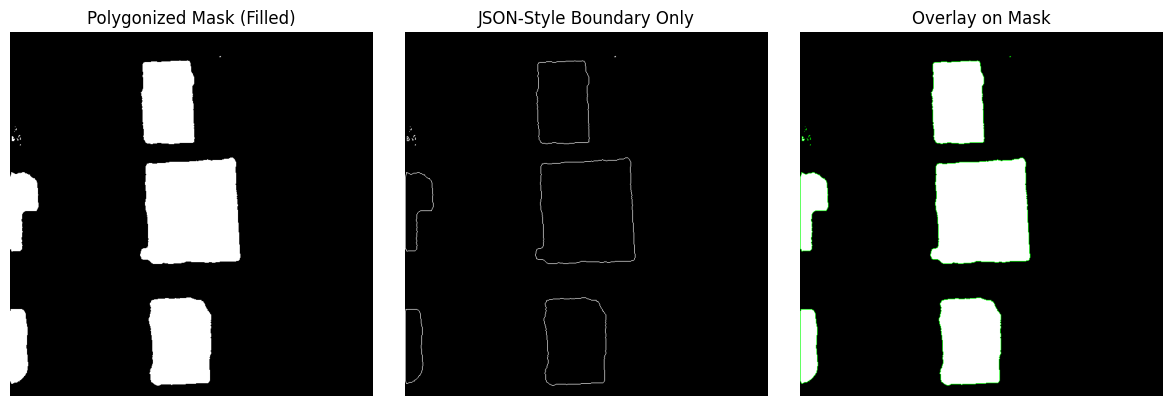

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_json_style_boundary(polygonized_mask):
    # Ensure input is uint8
    if polygonized_mask.max() <= 1:
        polygonized_mask = (polygonized_mask * 255).astype(np.uint8)
    else:
        polygonized_mask = polygonized_mask.astype(np.uint8)

    # Find contours (only external)
    contours, _ = cv2.findContours(polygonized_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Make a boundary-only image
    boundary_only = np.zeros_like(polygonized_mask)
    cv2.drawContours(boundary_only, contours, -1, color=255, thickness=1)

    # Make an RGB overlay to show boundary on original mask
    overlay = cv2.cvtColor(polygonized_mask, cv2.COLOR_GRAY2BGR)
    overlay[boundary_only == 255] = [0, 255, 0]  # Draw boundary in green

    # Show results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(polygonized_mask, cmap='gray')
    plt.title("Polygonized Mask (Filled)")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(boundary_only, cmap='gray')
    plt.title("JSON-Style Boundary Only")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay on Mask")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    return boundary_only

# Example usage
# polygonized_mask = cv2.imread("polygon_mask.png", cv2.IMREAD_GRAYSCALE)  # Or your variable
# visualize_json_style_boundary(polygonized_mask)

# If your mask is already in memory from earlier:
boundary_only=visualize_json_style_boundary(mask_array)  # Assuming 'poly_mask' is from earlier step


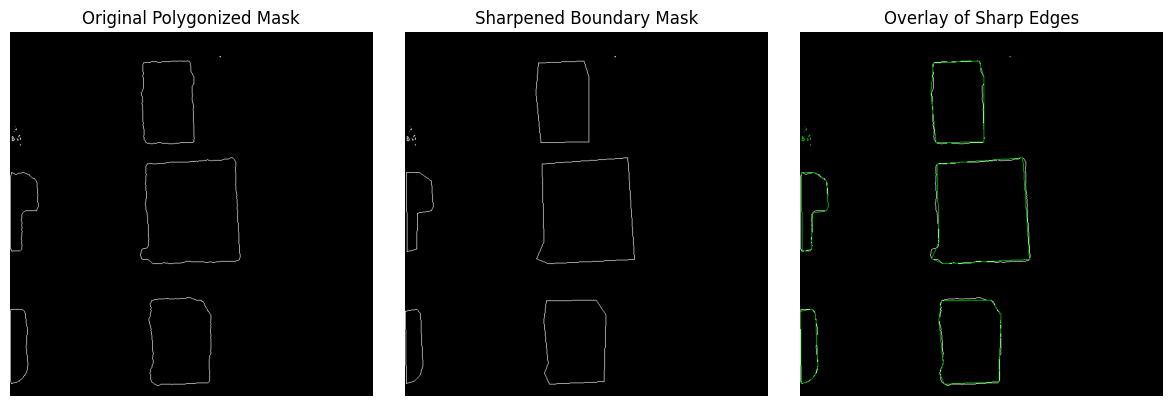

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sharpen_boundary(mask, epsilon_ratio=0.01):
    """
    Given a binary mask (0/255 or 0/1), this returns a sharpened boundary-only version.
    """
    if mask.max() <= 1:
        mask = (mask * 255).astype(np.uint8)
    else:
        mask = mask.astype(np.uint8)

    # Threshold to ensure binary
    _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create empty image for sharp boundary mask
    sharp_boundary = np.zeros_like(mask)

    # Approximate and draw sharp contours
    for cnt in contours:
        epsilon = epsilon_ratio * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        cv2.drawContours(sharp_boundary, [approx], -1, color=255, thickness=1)

    # Visualization
    overlay = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    overlay[sharp_boundary == 255] = [0, 255, 0]  # Green edges

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(mask, cmap='gray')
    plt.title("Original Polygonized Mask")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(sharp_boundary, cmap='gray')
    plt.title("Sharpened Boundary Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay of Sharp Edges")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return sharp_boundary

# Example usage:
sharpened = sharpen_boundary(boundary_only)


In [ ]:
sharpened

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

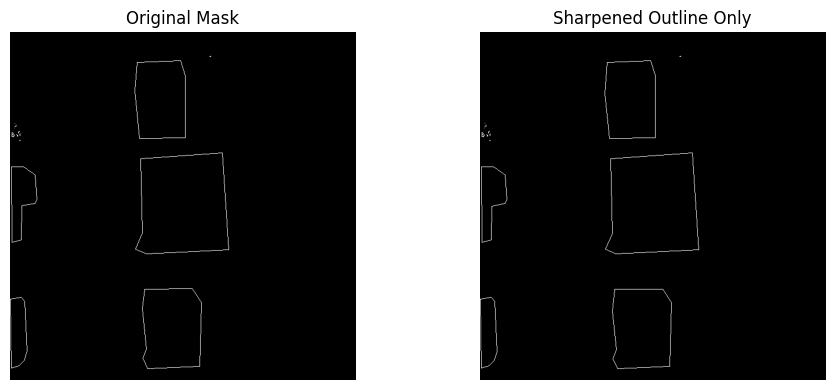

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_sharp_outline(mask, epsilon_ratio=0.01):
    if mask.max() <= 1:
        mask = (mask * 255).astype(np.uint8)
    else:
        mask = mask.astype(np.uint8)

    # Binarize mask
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create empty image for outline
    outline = np.zeros_like(mask)

    for cnt in contours:
        epsilon = epsilon_ratio * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        cv2.drawContours(outline, [approx], -1, color=255, thickness=1)  # thickness=1 for outline only

    return outline
outline_mask = get_sharp_outline(sharpened)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sharpened, cmap='gray')
plt.title("Original Mask")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(outline_mask, cmap='gray')
plt.title("Sharpened Outline Only")
plt.axis('off')

plt.tight_layout()
plt.show()


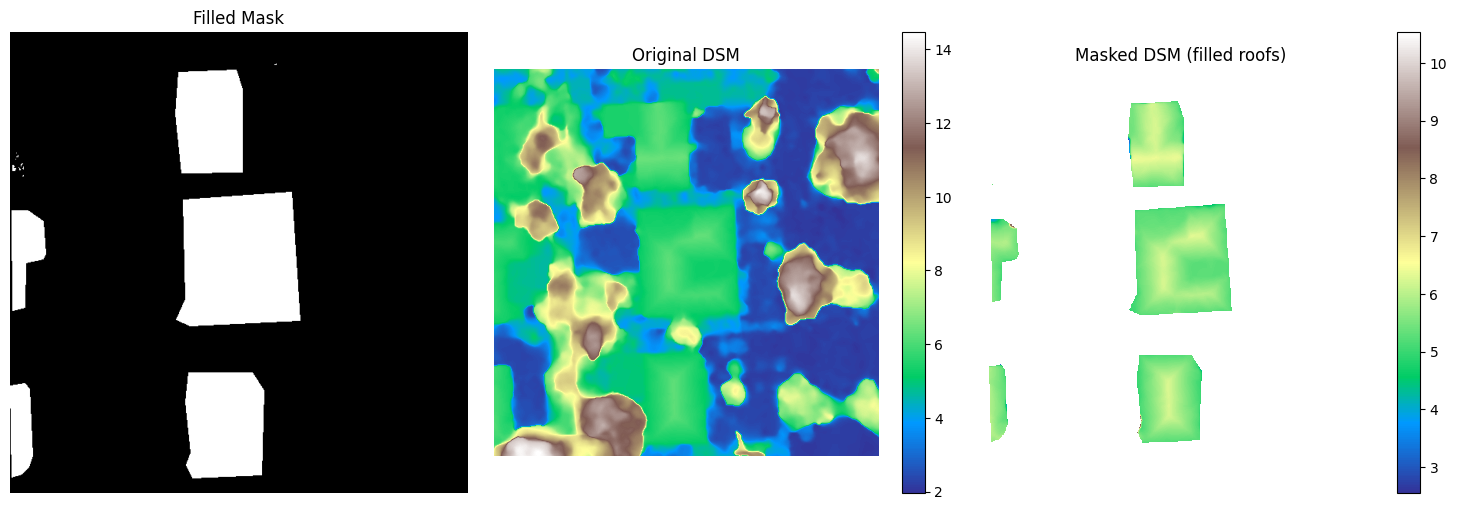

In [ ]:
# Suppose you start from an outline mask (0 and 255), get contours first:
contours, _ = cv2.findContours(outline_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Convert contours dtype to int32 if needed:
contours_int = [cnt.astype(np.int32) for cnt in contours]

# Create blank mask of DSM shape
filled_mask = np.zeros((dsm.shape[0], dsm.shape[1]), dtype=np.uint8)

# Fill the polygons
cv2.fillPoly(filled_mask, contours_int, color=1)

# Now apply mask
dsm_masked = np.where(filled_mask == 1, dsm, np.nan)

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(filled_mask, cmap='gray')
plt.title('Filled Mask')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(dsm, cmap='terrain')
plt.title('Original DSM')
plt.colorbar()
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(dsm_masked, cmap='terrain')
plt.title('Masked DSM (filled roofs)')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()


C:\Users\adity\AppData\Local\Temp\ipykernel_43324\2918025747.py:35: RuntimeWarning: invalid value encountered in cast
  normals_rgb = ((normal_dsm_masked + 1) / 2 * 255).astype(np.uint8)


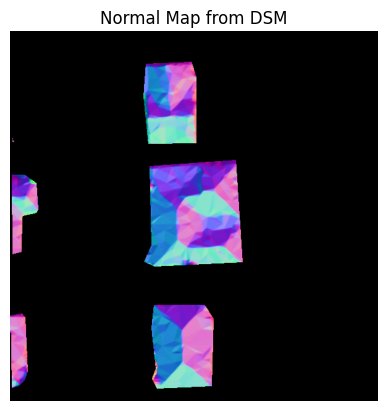

In [ ]:

def create_normal_map(dsm):
    """
    Create a normal map from DSM data.

    Parameters:
    - dsm: numpy array of shape (1, x, y) or (x, y)

    Returns:
    - normal_map: numpy array of shape (3, x, y)
    """
    # Ensure the input is a 2D array
    if dsm.ndim == 3:
        dsm = dsm[0]  # If input is (1, x, y), extract the 2D DSM

    # Compute the gradients (slopes)
    dx = np.gradient(dsm, axis=1)  # Gradient in x direction (width)
    dy = np.gradient(dsm, axis=0)  # Gradient in y direction (height)

    # Create normal vector components
    normal_x = -dx  # Inverse gradient for x-direction
    normal_y = -dy  # Inverse gradient for y-direction
    normal_z = np.ones_like(dsm)  # z-component (assumed to be 1)

    # Stack the normal components
    normals = np.stack((normal_x, normal_y, normal_z), axis=0)  # shape: (3, x, y)

    # Normalize the normal vectors
    norm = np.linalg.norm(normals, axis=0, keepdims=True)
    normals_normalized = normals / (norm + 1e-8)  # Avoid division by zero

    return normals_normalized
normal_dsm_masked = create_normal_map(dsm_masked*50)

# Normalize the normal map for display
normals_rgb = ((normal_dsm_masked + 1) / 2 * 255).astype(np.uint8)

# Plot the normal map
plt.imshow(np.transpose(normals_rgb, (1, 2, 0)))  # Transpose to (x, y, 3)
plt.title("Normal Map from DSM")
plt.axis('off')
plt.show()




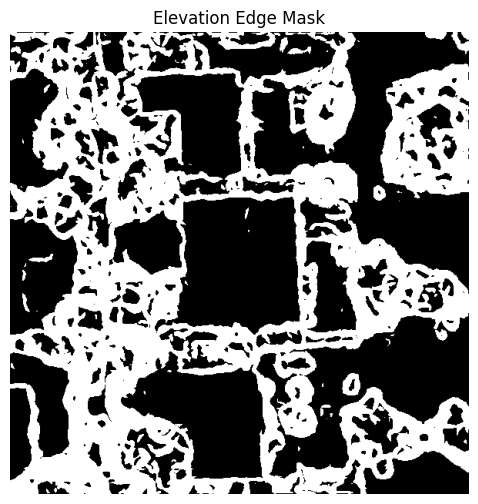

In [ ]:
import numpy as np
from scipy.ndimage import sobel

def compute_elevation_edges(dsm, threshold_factor=.45):
    dsm_clean = np.nan_to_num(dsm, nan=0.0)  # Replace NaNs with 0
    dx = sobel(dsm_clean, axis=1)
    dy = sobel(dsm_clean, axis=0)
    grad = np.hypot(dx, dy)
    threshold = threshold_factor * np.mean(grad)
    return grad > threshold

edge_mask=compute_elevation_edges(dsm)

plt.figure(figsize=(12, 6))  # creates the figure
plt.imshow(edge_mask.squeeze(), cmap='gray')  # plots image
plt.axis('off')  # hides axis
plt.title("Elevation Edge Mask")
plt.show()

c:\Users\adity\miniconda3\envs\pytorch-gpu-env\lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


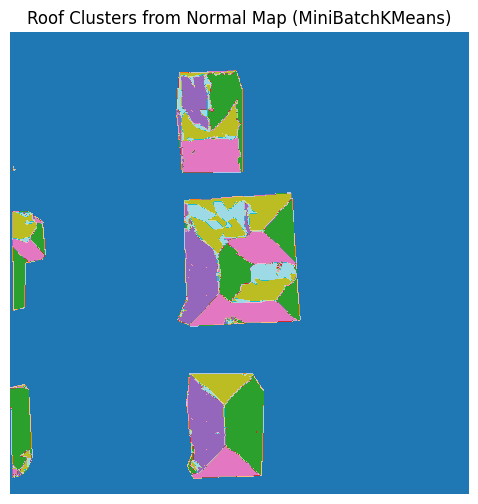

In [ ]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

# Assume: normals is (3, H, W)
H, W = normals_rgb.shape[1], normals_rgb.shape[2]

# Reshape to (N, 3)
normals_flat = normals_rgb.transpose(1, 2, 0).reshape(-1, 3)

# Filter invalid (e.g., zero-length) vectors
mag = np.linalg.norm(normals_flat, axis=1)
valid_mask = mag > 1e-3
normals_valid = normals_flat[valid_mask]

# Normalize the vectors
normals_valid = normalize(normals_valid)

# MiniBatchKMeans
n_clusters = 5 # Over-segment intentionally
kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=10000, random_state=42)
labels_valid = kmeans.fit_predict(normals_valid)

# Rebuild full image
labels_full = np.full((H * W,), -1, dtype=np.int32)
labels_full[valid_mask] = labels_valid
labels_img = labels_full.reshape(H, W)

# Visualize
plt.figure(figsize=(10, 6))
plt.imshow(labels_img, cmap='tab20')
plt.title("Roof Clusters from Normal Map (MiniBatchKMeans)")
plt.axis('off')
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def merge_similar_clusters(normals, labels_img, angle_thresh_deg=20):
    H, W = labels_img.shape
    flat_labels = labels_img.flatten()
    unique_labels = np.unique(flat_labels[flat_labels != -1])

    # Step 1: Compute mean normal for each cluster
    normals_flat = normals.transpose(1, 2, 0).reshape(-1, 3)
    cluster_normals = {}

    for lbl in unique_labels:
        idxs = np.where(flat_labels == lbl)[0]
        if len(idxs) == 0:
            continue
        cluster_vecs = normals_flat[idxs]
        mean_normal = np.mean(cluster_vecs, axis=0)
        mean_normal /= np.linalg.norm(mean_normal) + 1e-8
        cluster_normals[lbl] = mean_normal

    # Step 2: Compare pairwise angles and merge similar ones
    labels = list(cluster_normals.keys())
    vectors = np.array([cluster_normals[l] for l in labels])

    cos_sim = cosine_similarity(vectors)
    angle_diff = np.degrees(np.arccos(np.clip(cos_sim, -1, 1)))

    # Initialize merged label map
    label_map = {lbl: lbl for lbl in labels}
    next_label = 0
    visited = set()

    for i, lbl1 in enumerate(labels):
        if lbl1 in visited:
            continue
        label_map[lbl1] = next_label
        visited.add(lbl1)
        for j, lbl2 in enumerate(labels):
            if lbl2 in visited:
                continue
            if angle_diff[i, j] < angle_thresh_deg:
                label_map[lbl2] = next_label
                visited.add(lbl2)
        next_label += 1

    # Step 3: Remap all labels
    merged_labels_flat = np.full_like(flat_labels, -1)
    for old_lbl, new_lbl in label_map.items():
        merged_labels_flat[flat_labels == old_lbl] = new_lbl

    return merged_labels_flat.reshape(H, W)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


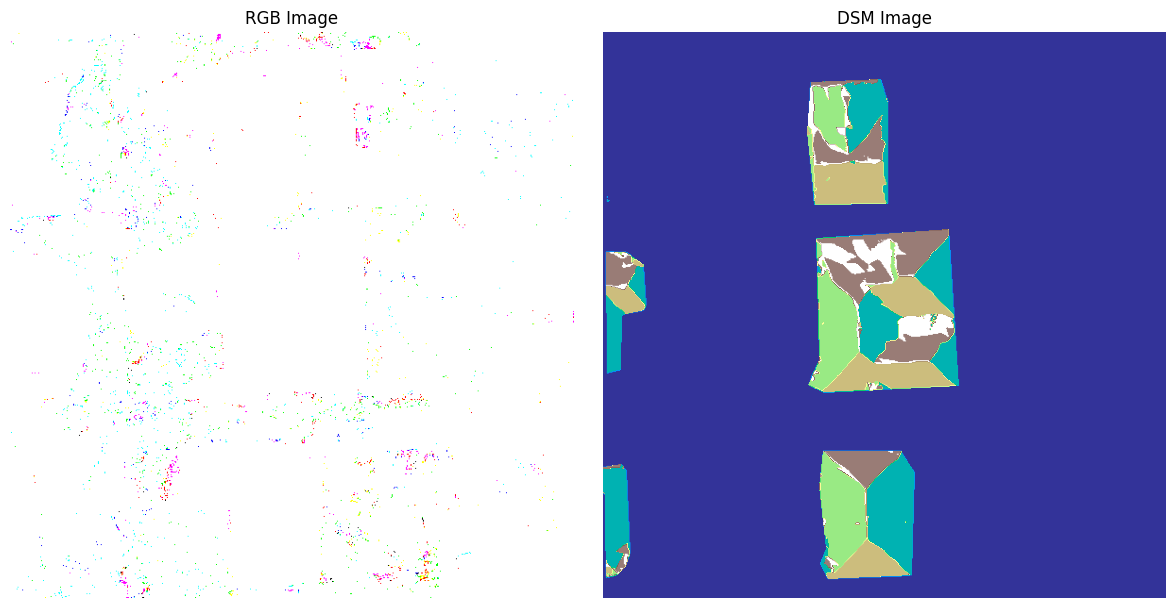

In [ ]:
merged_labels_img = merge_similar_clusters(normals_rgb, labels_img, angle_thresh_deg=10)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display RGB (First 3 channels)
rgb_img = np.moveaxis(rgb[:3], 0, -1)  # Convert (Bands, H, W) → (H, W, Bands)
axes[0].imshow(rgb_img)
axes[0].set_title("RGB Image")
axes[0].axis("off")

# Display DSM (First band, grayscale)
axes[1].imshow(merged_labels_img, cmap="terrain")  # DSM is single-channel
axes[1].set_title("DSM Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.ndimage import distance_transform_edt
import numpy as np

def remove_and_reassign_small_segments(segmentation, min_pixels=500):
    """
    Removes small segments and reassigns them to the nearest large segment without merging them into background.
    All segments retain valid cluster labels (> 0).
    """
    output = segmentation.copy()
    unique_labels = np.unique(segmentation)

    # Identify small segments
    small_mask = np.zeros_like(segmentation, dtype=bool)
    large_mask = np.zeros_like(segmentation, dtype=bool)

    for label in unique_labels:
        if label < 0:
            continue
        mask = (segmentation == label)
        num_pixels = np.sum(mask)

        if num_pixels < min_pixels:
            small_mask |= mask
        else:
            large_mask |= mask

    # If nothing to reassign, return early
    if not np.any(small_mask):
        return output

    # Use EDT to find nearest large segment label for small segment pixels
    distance, indices = distance_transform_edt(~large_mask, return_indices=True)
    reassigned_labels = segmentation[tuple(indices)]

    # Assign only small segment pixels to nearest large segment
    output[small_mask] = reassigned_labels[small_mask]

    return output


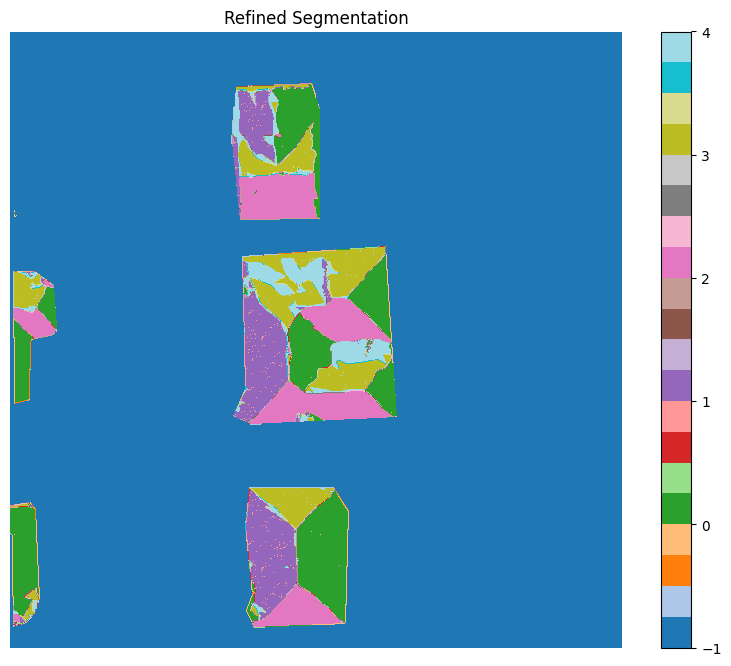

In [ ]:
min_pixels = 0.001 * dsm.shape[0] * dsm.shape[1]
filtered = remove_and_reassign_small_segments(merged_labels_img, min_pixels)
plt.figure(figsize=(10, 8))
plt.imshow(filtered, cmap='tab20')  # or 'nipy_spectral', or 'viridis' for visual contrast
plt.title("Refined Segmentation")
plt.axis('off')
plt.colorbar()
plt.show()


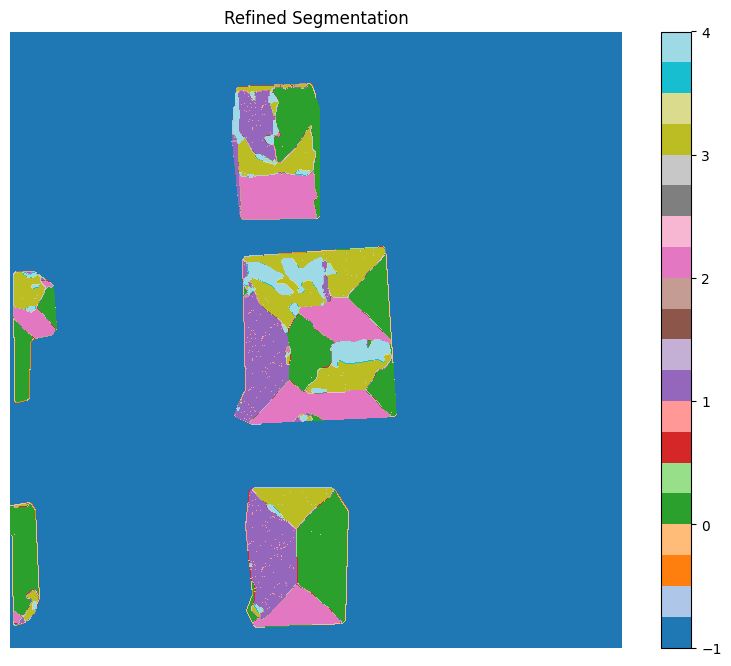

In [ ]:
from scipy.ndimage import median_filter

# Apply a median filter to smooth the label map
smoothed_labels = median_filter(filtered, size=5)
plt.figure(figsize=(10, 8))
plt.imshow(smoothed_labels, cmap='tab20')  # or 'nipy_spectral', or 'viridis' for visual contrast
plt.title("Refined Segmentation")
plt.axis('off')
plt.colorbar()
plt.show()


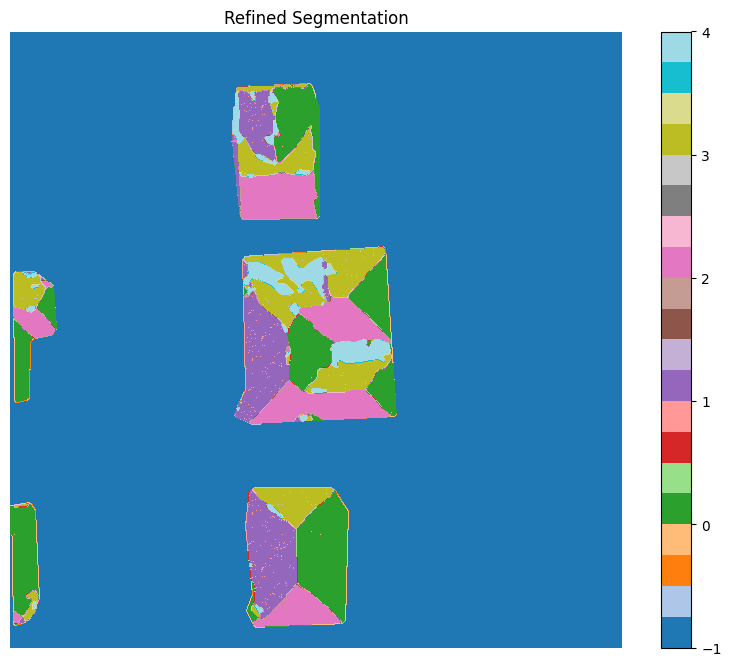

In [ ]:
import cv2

def morphological_close_labels(label_map, kernel_size=3):
    closed = np.full_like(label_map, -1)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))

    for lbl in np.unique(label_map):
        if lbl == -1:
            continue
        mask = (label_map == lbl).astype(np.uint8)
        closed_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        closed[closed_mask == 1] = lbl

    return closed

labels_closed = morphological_close_labels(smoothed_labels)

plt.figure(figsize=(10, 8))
plt.imshow(labels_closed, cmap='tab20')  # or 'nipy_spectral', or 'viridis' for visual contrast
plt.title("Refined Segmentation")
plt.axis('off')
plt.colorbar()
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def extract_polygons_from_labels(label_img, epsilon_ratio=0.01):
    """
    Extract polygonal contours from labeled clusters using approxPolyDP.
    Args:
        label_img: 2D array of integer labels.
        epsilon_ratio: fraction of the perimeter for contour approximation.
    Returns:
        dict: {label: list of polygon points}
    """
    h, w = label_img.shape
    polygons = {}

    unique_labels = np.unique(label_img)
    for lbl in unique_labels:
        if lbl == -1:
            continue

        mask = (label_img == lbl).astype(np.uint8)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        # Pick the largest contour for this label
        contour = max(contours, key=cv2.contourArea)
        epsilon = epsilon_ratio * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        polygons[lbl] = approx.squeeze()  # shape: (N, 2)

    return polygons


c:\Users\adity\miniconda3\envs\pytorch-gpu-env\lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


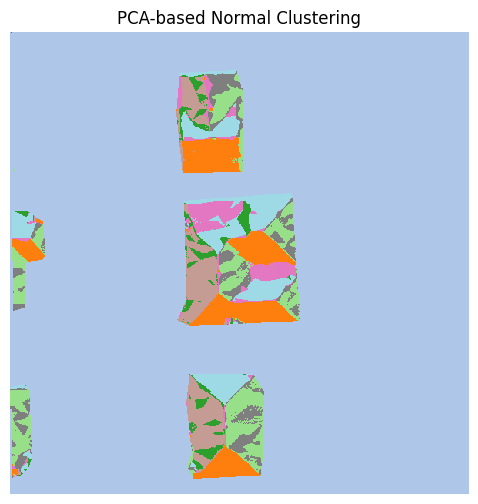

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

def cluster_normals_with_pca(normals, mask=None, n_clusters=50, pca_components=3):
    """
    Clusters surface normals using PCA-reduced components.
    
    Args:
        normals: (3, H, W) array of unit normals
        mask: optional binary mask (H, W) to restrict clustering
        n_clusters: number of KMeans clusters
        pca_components: typically 2 or 3

    Returns:
        clustered_labels: (H, W) array of cluster labels (-1 outside mask)
    """
    C, H, W = normals.shape
    assert C == 3, "Normals must be (3, H, W)"

    # Prepare data
    flat_normals = normals.reshape(3, -1).T  # shape (H*W, 3)

    if mask is not None:
        flat_mask = mask.flatten()
        valid_indices = np.where(flat_mask)[0]
        valid_normals = flat_normals[valid_indices]
    else:
        valid_indices = np.arange(flat_normals.shape[0])
        valid_normals = flat_normals

    # PCA
    pca = PCA(n_components=pca_components)
    reduced = pca.fit_transform(valid_normals)

    # KMeans
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=0)
    cluster_labels = kmeans.fit_predict(reduced)

    # Reconstruct full label image
    labels_full = np.full(flat_normals.shape[0], -1, dtype=np.int32)
    labels_full[valid_indices] = cluster_labels
    return labels_full.reshape(H, W)
clustered = cluster_normals_with_pca(normals_rgb, mask=dsm_masked, n_clusters=15)

plt.figure(figsize=(10, 6))
plt.imshow(clustered, cmap='tab20', interpolation='nearest')
plt.title("PCA-based Normal Clustering")
plt.axis('off')
plt.show()


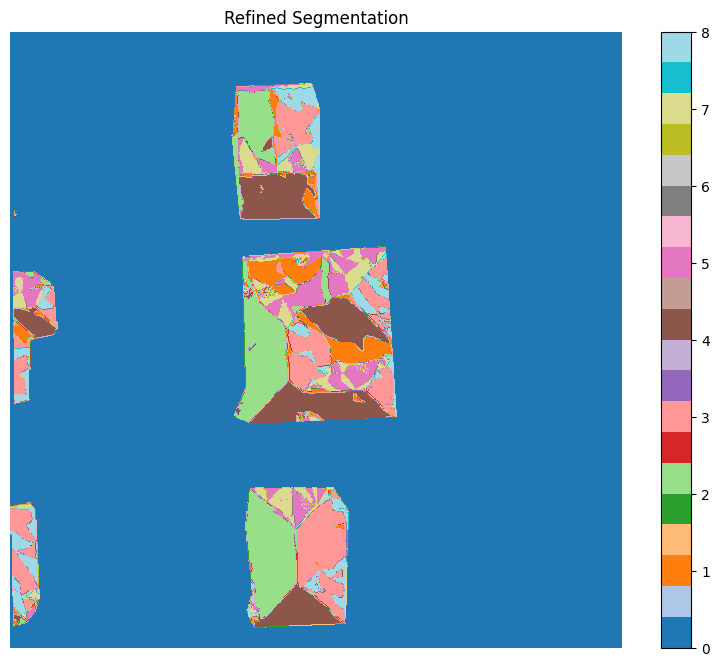

In [ ]:
min_pixels = 0.001 * dsm.shape[0] * dsm.shape[1]
filtered_pca = remove_and_reassign_small_segments(clustered, min_pixels)
plt.figure(figsize=(10, 8))
plt.imshow(filtered, cmap='tab20')  # or 'nipy_spectral', or 'viridis' for visual contrast
plt.title("Refined Segmentation")
plt.axis('off')
plt.colorbar()
plt.show()


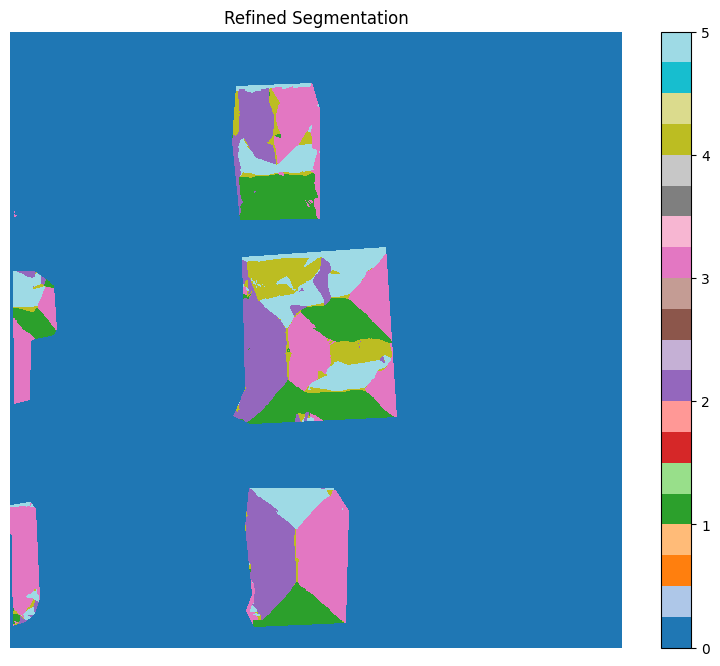

In [ ]:
merged_labels_img_pca = merge_similar_clusters(normals_rgb, filtered_pca, angle_thresh_deg=10)




# Display RGB (First 3 channels)
plt.figure(figsize=(10, 8))
plt.imshow(merged_labels_img_pca, cmap='tab20',interpolation='nearest')  # or 'nipy_spectral', or 'viridis' for visual contrast
plt.title("Refined Segmentation")
plt.axis('off')
plt.colorbar()
plt.show()

c:\Users\adity\miniconda3\envs\pytorch-gpu-env\lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


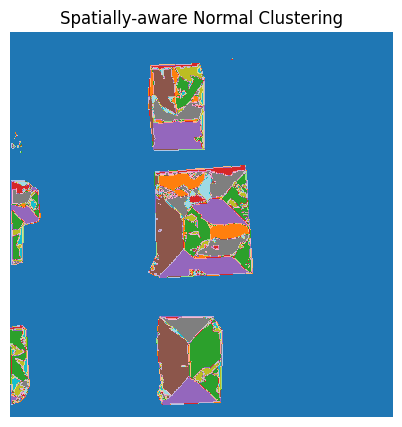

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

def cluster_with_spatial_coords(normals, mask, n_clusters=15, spatial_weight=50.0, pca_components=3):
    """
    Cluster roof regions using normals + spatial coordinates (geometry-aware).
    Parameters:
        normals: [3, H, W] normal vector map
        mask: [H, W] binary mask (255=valid, 0=ignore)
        n_clusters: number of KMeans clusters
        spatial_weight: factor to downscale spatial coords relative to normals
        pca_components: number of PCA components to keep before clustering
    Returns:
        clustered_img: [H, W] label image with cluster ids, -1 for background
    """
    H, W = mask.shape

    # Flatten normals and mask
    normals = normals[:, :H, :W]
    normals_flat = normals.transpose(1, 2, 0).reshape(-1, 3)
    mask_flat = (mask.flatten() > 0)

    # Generate spatial coordinates
    Y, X = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    coords = np.stack([X, Y], axis=-1).reshape(-1, 2)  # (H*W, 2)
    coords = coords / spatial_weight  # normalize relative to normals

    # Combine normals + coords
    features = np.concatenate([normals_flat, coords], axis=1)
    features_masked = features[mask_flat]

    # Apply PCA
    pca = PCA(n_components=pca_components)
    features_reduced = pca.fit_transform(features_masked)

    # MiniBatchKMeans clustering
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=1024)
    labels = kmeans.fit_predict(features_reduced)

    # Reconstruct label image
    clustered_img = np.full(H * W, -1, dtype=np.int32)
    clustered_img[mask_flat] = labels
    return clustered_img.reshape(H, W)
clustered_spatial = cluster_with_spatial_coords(normals_rgb, dsm_masked, n_clusters=10, spatial_weight=10.0)

# Visualize
plt.figure(figsize=(10, 5))
plt.imshow(clustered_spatial, cmap='tab20')
plt.title("Spatially-aware Normal Clustering")
plt.axis('off')
plt.show()


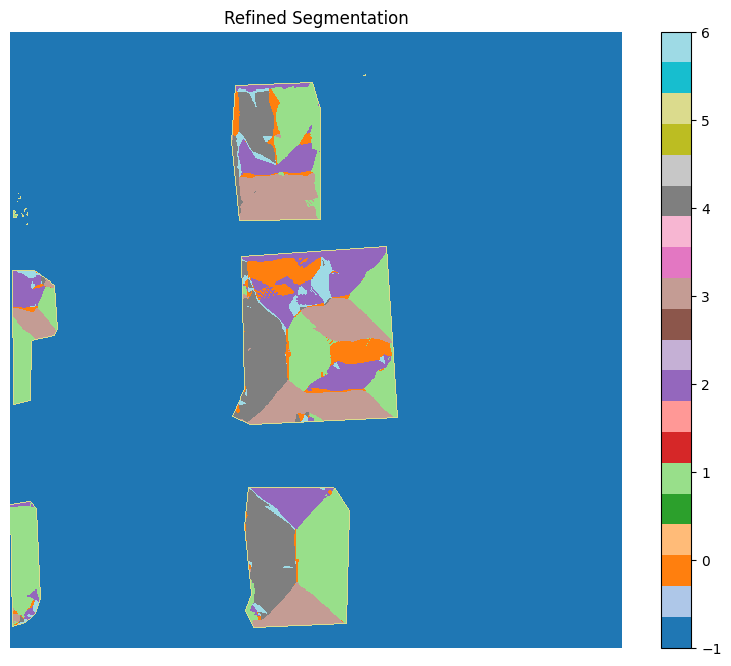

In [ ]:
merged_labels_img_spatial = merge_similar_clusters(normals_rgb, clustered_spatial, angle_thresh_deg=10)




# Display RGB (First 3 channels)
plt.figure(figsize=(10, 8))
plt.imshow(merged_labels_img_spatial, cmap='tab20',interpolation='nearest')  # or 'nipy_spectral', or 'viridis' for visual contrast
plt.title("Refined Segmentation")
plt.axis('off')
plt.colorbar()
plt.show()

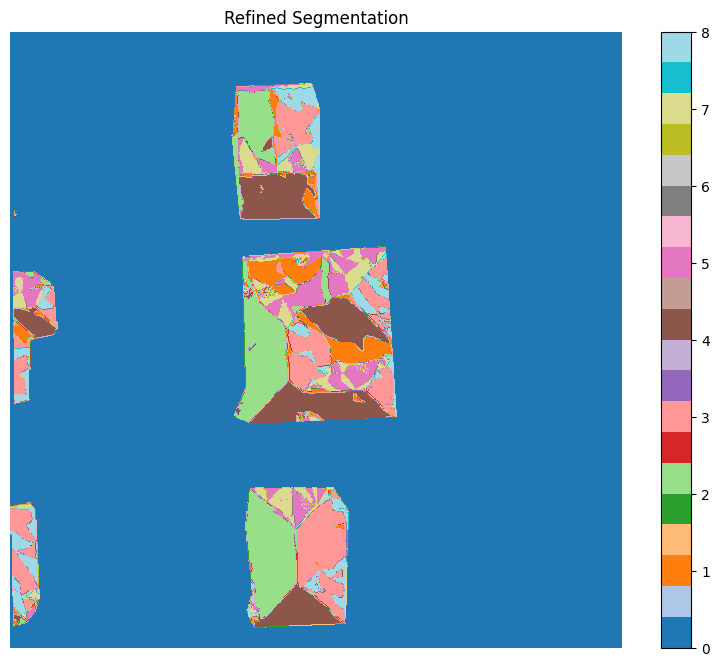

In [ ]:
min_pixels = 0.001 * dsm.shape[0] * dsm.shape[1]
filtered_pca = remove_and_reassign_small_segments(merged_labels_img_spatial, min_pixels)
plt.figure(figsize=(10, 8))
plt.imshow(filtered, cmap='tab20')  # or 'nipy_spectral', or 'viridis' for visual contrast
plt.title("Refined Segmentation")
plt.axis('off')
plt.colorbar()
plt.show()


Using bandwidth: 56.706


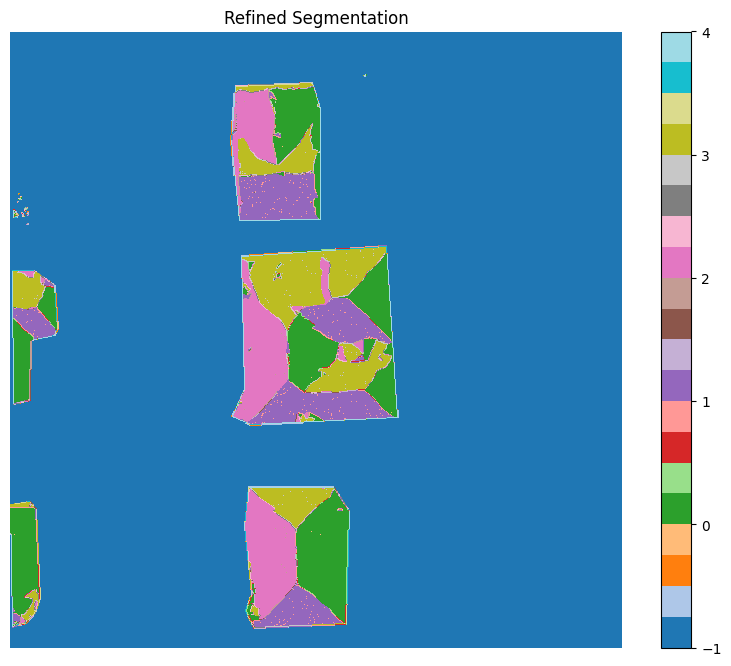

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import MeanShift, estimate_bandwidth

def mean_shift_clustering(normals, elevation, mask, spatial_weight=40.0, pca_components=3, bandwidth=None):
    H, W = mask.shape
    mask_flat = mask.flatten() > 0

    # Flatten and align
    normals_flat = normals.transpose(1, 2, 0).reshape(-1, 3)
    elevation_flat = elevation.flatten().reshape(-1, 1)

    # Spatial coordinates
    Y, X = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    coords_flat = np.stack([X, Y], axis=-1).reshape(-1, 2) / spatial_weight

    # Combine all features
    features = np.concatenate([normals_flat, elevation_flat, coords_flat], axis=1)
    features_masked = features[mask_flat]

    # Optional PCA to denoise
    if pca_components:
        pca = PCA(n_components=pca_components)
        features_masked = pca.fit_transform(features_masked)

    # Estimate bandwidth if not provided
    if bandwidth is None:
        bandwidth = estimate_bandwidth(features_masked, quantile=0.2, n_samples=100)

    print(f"Using bandwidth: {bandwidth:.3f}")

    # Run Mean Shift clustering
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    labels = ms.fit_predict(features_masked)

    # Map back to full image
    clustered = np.full(H * W, -1, dtype=np.int32)
    clustered[mask_flat] = labels
    return clustered.reshape(H, W)
# Your inputs:
# normals: (3, H, W) — from normal estimation step
# elevation: (H, W) — your DSM (masked or original)
# mask: (H, W) — binary mask of the roof area

clustered_means = mean_shift_clustering(normals_rgb, dsm_masked, dsm_masked)
plt.figure(figsize=(10, 8))
plt.imshow(clustered_means, cmap='tab20')  # or 'nipy_spectral', or 'viridis' for visual contrast
plt.title("Refined Segmentation")
plt.axis('off')
plt.colorbar()
plt.show()


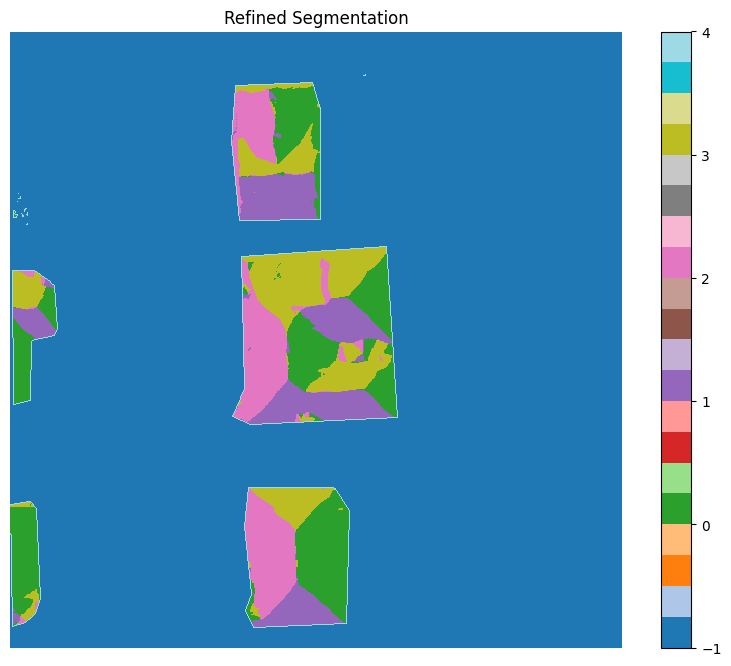

In [ ]:
merged_labels_img_means = merge_similar_clusters(normals_rgb, clustered_means, angle_thresh_deg=10)




# Display RGB (First 3 channels)
plt.figure(figsize=(10, 8))
plt.imshow(merged_labels_img_means, cmap='tab20',interpolation='nearest')  # or 'nipy_spectral', or 'viridis' for visual contrast
plt.title("Refined Segmentation")
plt.axis('off')
plt.colorbar()
plt.show()

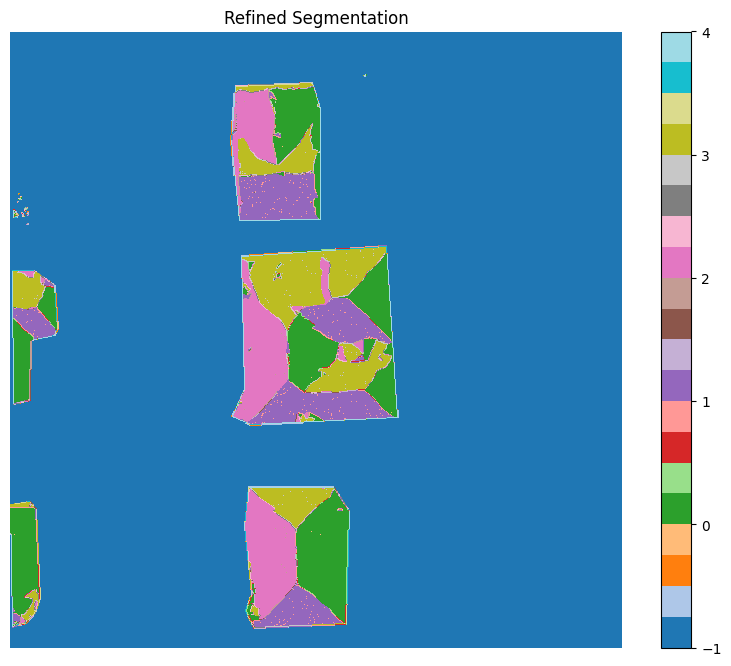

In [ ]:
min_pixels = 0.005 * dsm.shape[0] * dsm.shape[1]
filtered_means = remove_and_reassign_small_segments(merged_labels_img_means, min_pixels)
plt.figure(figsize=(10, 8))
plt.imshow(filtered_means, cmap='tab20')  # or 'nipy_spectral', or 'viridis' for visual contrast
plt.title("Refined Segmentation")
plt.axis('off')
plt.colorbar()
plt.show()


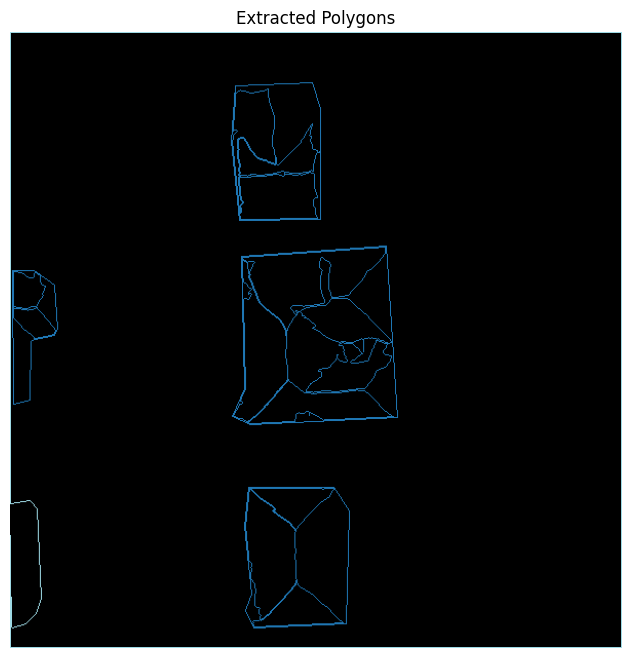

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def extract_polygons_from_segmentation(segmentation):
    """
    Extract polygon contours from a segmentation mask.

    Parameters:
    - segmentation: 2D numpy array of integer labels.

    Returns:
    - List of polygons per label, where each polygon is a list of (x, y) points.
    """
    polygons_per_label = {}

    unique_labels = np.unique(segmentation)
    for label in unique_labels:
        if label == 0:  # Skip background if needed
            continue

        mask = (segmentation == label).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        polygons = []
        for cnt in contours:
            if cv2.contourArea(cnt) < 500:  # Skip tiny polygons
                continue
            polygon = cnt[:, 0, :]  # Remove unnecessary nesting
            polygons.append(polygon)

        if polygons:
            polygons_per_label[label] = polygons

    return polygons_per_label

def label_to_color(label, max_label=100):
    """Map a label to an RGB color tuple."""
    cmap = plt.get_cmap('tab20', max_label)
    rgba = cmap(label % max_label)
    rgb = tuple(int(c * 255) for c in rgba[:3])  # (R, G, B)
    return rgb  # This is a tuple of 3 ints

def visualize_polygons(polygons_per_label, image_shape):
    canvas = np.zeros((*image_shape, 3), dtype=np.uint8)

    for label, polygons in polygons_per_label.items():
        color = label_to_color(int(label))  # Ensure label is an int
        for polygon in polygons:
            if polygon.shape[0] >= 3:  # Only draw if it's a valid polygon
                cv2.polylines(canvas, [polygon.astype(np.int32)], isClosed=True, color=color, thickness=1)

    plt.figure(figsize=(8, 8))
    plt.imshow(canvas)
    plt.title("Extracted Polygons")
    plt.axis('off')
    plt.show()
polygons_per_label = extract_polygons_from_segmentation(merged_labels_img_means)
visualize_polygons(polygons_per_label, merged_labels_img_means.shape)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


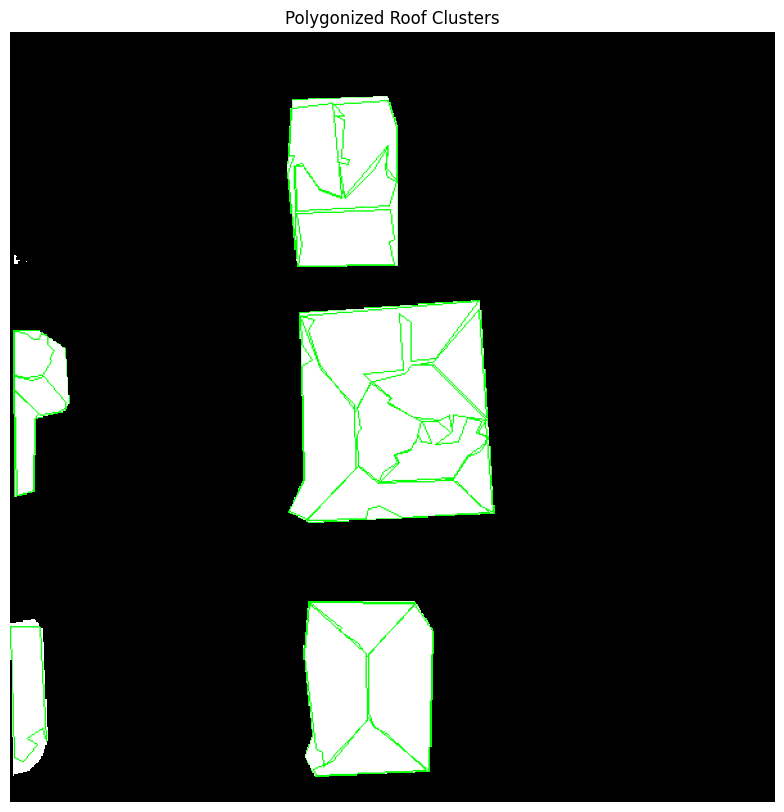

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def polygonize_clusters(label_image, min_area=500, epsilon_ratio=0.01):
    """
    Converts clustered regions into polygons using contours and approximations.

    Args:
        label_image (np.ndarray): 2D array of cluster labels.
        min_area (int): Minimum area to keep a contour (filters small noise).
        epsilon_ratio (float): Approximation accuracy as a fraction of perimeter.

    Returns:
        List of polygons (each polygon is a list of (x, y) points).
    """
    polygons = []
    unique_labels = np.unique(label_image)
    for label in unique_labels:
        if label == -1:
            continue
        mask = np.uint8(label_image == label)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < min_area:
                continue
            epsilon = epsilon_ratio * cv2.arcLength(cnt, True)
            approx = cv2.approxPolyDP(cnt, epsilon, True)
            polygon = approx.squeeze().tolist()
            if len(polygon) >= 3:
                polygons.append(polygon)
    return polygons
# polygonize
polygons = polygonize_clusters(filtered_means)

# Visualize polygons over image
image_rgb = np.dstack([dsm_masked]*3)  # Or your original image
vis = image_rgb.copy()
for poly in polygons:
    pts = np.array(poly, dtype=np.int32).reshape((-1, 1, 2))
    cv2.polylines(vis, [pts], isClosed=True, color=(0, 255, 0), thickness=1)

plt.figure(figsize=(10, 10))
plt.imshow(vis)
plt.title("Polygonized Roof Clusters")
plt.axis('off')
plt.show()


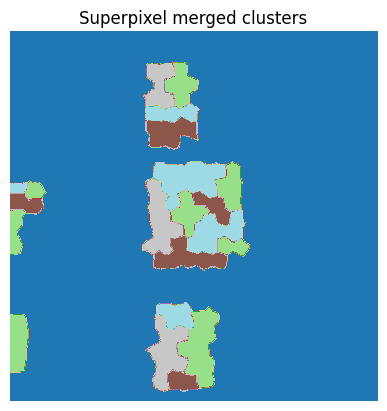

In [ ]:
import cv2
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def superpixel_region_merge(dsm, normals, initial_labels, num_superpixels=500, compactness=10.0, angle_thresh_deg=20):
    """
    Use SLIC superpixels + your normal-based clustering labels to create smoother clusters.

    Params:
    - dsm: (H,W) elevation map
    - normals: (3, H, W) normal vectors
    - initial_labels: (H, W) your existing cluster labels (e.g., MiniBatchKMeans output)
    - num_superpixels: int, number of SLIC superpixels
    - compactness: float, compactness parameter for SLIC
    - angle_thresh_deg: float, threshold to merge superpixels with similar normals

    Returns:
    - merged_labels: (H, W) smoothed cluster labels after superpixel merging
    """

    H, W = dsm.shape

    # Convert DSM to 3-channel image for SLIC (normalize to 0-255)
    dsm_norm = (255 * (dsm - np.min(dsm)) / (np.ptp(dsm) + 1e-8)).astype(np.uint8)
    dsm_3c = cv2.cvtColor(dsm_norm, cv2.COLOR_GRAY2BGR)

    # Create SLIC superpixels
    slic = cv2.ximgproc.createSuperpixelSLIC(dsm_3c, region_size=int(np.sqrt(H*W/num_superpixels)), ruler=compactness)
    slic.iterate(10)
    superpixel_mask = slic.getLabels()  # shape (H, W), superpixel IDs
    num_labels = slic.getNumberOfSuperpixels()

    # Compute average normal per superpixel
    normals_flat = normals.reshape(3, -1)
    superpixel_mask_flat = superpixel_mask.flatten()
    avg_normals = np.zeros((num_labels, 3), dtype=np.float32)

    for sp_id in range(num_labels):
        idxs = np.where(superpixel_mask_flat == sp_id)[0]
        if len(idxs) > 0:
            vecs = normals_flat[:, idxs].T
            mean_vec = np.mean(vecs, axis=0)
            mean_vec /= np.linalg.norm(mean_vec) + 1e-8
            avg_normals[sp_id] = mean_vec
        else:
            avg_normals[sp_id] = np.array([0,0,1], dtype=np.float32)

    # Compute average cluster label for each superpixel from initial_labels
    initial_labels_flat = initial_labels.flatten()
    superpixel_initial_labels = np.zeros(num_labels, dtype=np.int32)
    for sp_id in range(num_labels):
        idxs = np.where(superpixel_mask_flat == sp_id)[0]
        if len(idxs) > 0:
            # Majority voting for cluster label
            labels, counts = np.unique(initial_labels_flat[idxs], return_counts=True)
            superpixel_initial_labels[sp_id] = labels[np.argmax(counts)]
        else:
            superpixel_initial_labels[sp_id] = -1

    # Merge superpixels with similar normals and same initial cluster label
    merged_labels = superpixel_initial_labels.copy()
    merged = np.zeros(num_labels, dtype=bool)

    for i in range(num_labels):
        if merged[i]:
            continue
        for j in range(i+1, num_labels):
            if merged[j]:
                continue
            # Check cluster label equality
            if superpixel_initial_labels[i] != superpixel_initial_labels[j]:
                continue
            # Check angle between average normals
            cos_theta = np.clip(np.dot(avg_normals[i], avg_normals[j]), -1, 1)
            angle_deg = np.degrees(np.arccos(cos_theta))
            if angle_deg < angle_thresh_deg:
                merged_labels[j] = merged_labels[i]
                merged[j] = True

    # Create output image by mapping each pixel's superpixel label to merged label
    output_labels = np.zeros_like(superpixel_mask)
    for sp_id in range(num_labels):
        output_labels[superpixel_mask == sp_id] = merged_labels[sp_id]

    return output_labels

# --- Usage ---
# dsm: your DSM numpy array (H,W)
# normals: (3,H,W) normal vectors
# initial_labels: your previous clustering result (H,W)

smoothed_labels = superpixel_region_merge(dsm, normals_rgb, filtered_means, num_superpixels=600, compactness=20, angle_thresh_deg=15)

# Visualize
import matplotlib.pyplot as plt
plt.imshow(smoothed_labels, cmap='tab20')
plt.title("Superpixel merged clusters")
plt.axis('off')
plt.show()


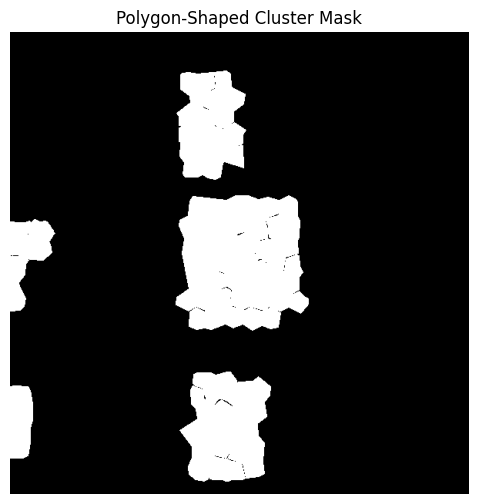

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def clean_mask(mask, kernel_size=3):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)
    return opened

def extract_polygons_from_clusters(label_map, min_area=300, epsilon_ratio=0.005, draw=False):
    H, W = label_map.shape
    polygon_mask = np.zeros((H, W), dtype=np.uint8)
    simplified_polygons = []

    unique_labels = np.unique(label_map)
    unique_labels = unique_labels[unique_labels != -1]

    for lbl in unique_labels:
        binary_mask = (label_map == lbl).astype(np.uint8)
        cleaned_mask = clean_mask(binary_mask)

        # Find connected components
        num_labels, cc_map, stats, _ = cv2.connectedComponentsWithStats(cleaned_mask, connectivity=8)
        for i in range(1, num_labels):  # Skip background
            if stats[i, cv2.CC_STAT_AREA] < min_area:
                continue
            region_mask = (cc_map == i).astype(np.uint8)

            contours, _ = cv2.findContours(region_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for cnt in contours:
                if len(cnt) < 3:
                    continue  # Not a polygon

                epsilon = epsilon_ratio * cv2.arcLength(cnt, True)
                approx = cv2.approxPolyDP(cnt, epsilon, True)

                simplified_polygons.append(approx)
                if draw:
                    cv2.drawContours(polygon_mask, [approx], -1, 255, -1)

    return polygon_mask, simplified_polygons
# Assuming 'labels_img' is your clustered image
polygon_mask, polygons = extract_polygons_from_clusters(smoothed_labels, draw=True)

plt.figure(figsize=(10, 6))
plt.imshow(polygon_mask, cmap='gray')
plt.title("Polygon-Shaped Cluster Mask")
plt.axis('off')
plt.show()

